# 00 · Datos y features

Descarga el panel de mercado, construye los 20 canales causales de `X`, calcula
las variables objetivo y termina con un EDA de lo que va a ver el generador.

**Entradas:** `data/catalog.yaml`

**Salidas:** `data/raw/precios.parquet` · `data/processed/canales.parquet` ·
`data/processed/objetivos.parquet` · 5 figuras en `results/figures/`

**Tiempo:** ~5 min la primera vez (descarga de yfinance); ~30 s con caché.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import matplotlib.pyplot as plt

from src import calidad, datos, features, ventanas

# El catálogo se cachea por sesión: sin esto, editar el YAML con el kernel vivo
# regeneraría los canales con la versión antigua y en silencio.
config.cargar_catalogo.cache_clear()

## 1 · Qué descargamos

15 activos de yfinance, de 2003 a 2026: el S&P 500, sus nueve ETF sectoriales, el
VIX, tres ETF de renta fija y el índice dólar. Todo sale de `data/catalog.yaml`;
aquí no hay ni un ticker escrito a mano.

Tres cosas que mirar en la salida:

- **La huella.** yfinance reescribe su histórico, así que dos descargas en fechas
  distintas no dan lo mismo. Esta firma del contenido dice si dos personas están
  trabajando sobre los mismos números.
- **La auditoría de integridad.** Diez controles sobre el panel. Los cinco
  primeros son invariantes —cosas imposibles en datos correctos— y lanzan
  excepción; los otros cinco son avisos, porque lo inverosímil aquí a veces es
  cierto: el mayor salto del panel es un VIX de +115,6 % el 5 de febrero de 2018,
  y es un dato bueno. **No se limpia nada**: winsorizar al 1 % bajaría la curtosis
  de 16,5 a 6,4, por debajo de la que produce nuestro propio generador gaussiano.
- **Quién manda en la fecha de inicio.** TLT, IEF y LQD no existen antes de
  julio de 2002, y por eso el periodo arranca en 2003.

Panel: (5942, 15) · 2003-01-02 a 2026-08-14
Huella del contenido: caf9f9c20c2d
           ticker         rol desde_fuente inicio_panel  limita_arranque
nombre                                                                  
tesoro_20y    TLT  renta_fija   2002-07-30   2003-01-02             True
tesoro_10y    IEF  renta_fija   2002-07-30   2003-01-02             True
credito_ig    LQD  renta_fija   2002-07-30   2003-01-02             True


,veredicto,medida,limite,donde
control,,,,
tipos,ok,0.0,0.0,todo float64 + DatetimeIndex naive
indice,ok,0.0,0.0,dup=0 desorden=0 fin_semana=0
finitud,ok,0.0,0.0,sin NaN ni inf
positividad,ok,0.0,0.0,mínimo global 3.67
degeneradas,ok,0.0,0.0,corr máxima fuera de la diagonal 0.911
congelados,ok,3.0,3.0,"sector_materiales, racha de 3 sesiones"
saltos,ok,27.0,50.0,credito_ig 2008-09-29
calendario,ok,5.0,10.0,2006-12-29 a 2007-01-03
densidad,ok,250.0,240.0,mínimo en 2012 (250 sesiones)


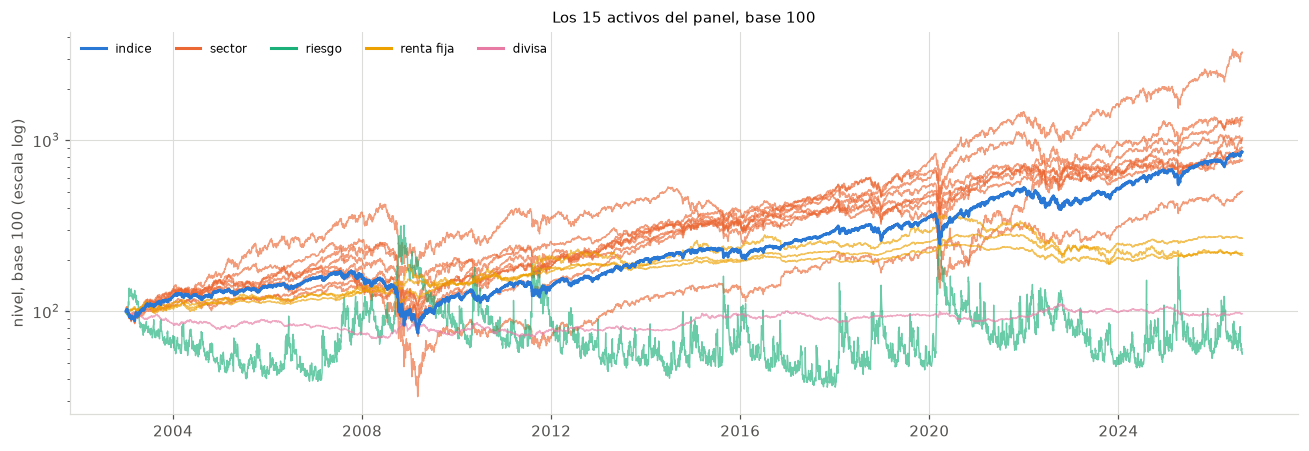

In [3]:
precios = datos.descargar_precios()

print("Panel:", precios.shape, "·", precios.index[0].date(), "a", precios.index[-1].date())
print("Huella del contenido:", datos.huella(precios))
print(datos.cobertura(precios).head(3).to_string())

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.panel_mercado(precios, eje=eje)
viz.guardar(fig, "panel_mercado")

calidad.auditar_panel(precios)

## 2 · De precios a `X`: 20 canales causales

Los precios en crudo no sirven como entrada: mezclan niveles y escalas. Se derivan
20 canales —11 de retorno y 9 de estrés— que son lo que verá el modelo.

**Todos son causales**: el valor en `t` solo usa información de `t` o anterior. El
error clásico es el z-score sobre la muestra completa, que mejora las métricas
porque el modelo acaba conociendo la media del futuro.

El contraste lo comprueba canal a canal, aplicando cada transformación a la serie
entera y a un prefijo, y busca **dos** formas distintas de mirar al futuro:

| columna | caza transformaciones que… | ejemplo |
|---|---|---|
| `discrepancia` | **reescriben** el pasado | z-score global |
| `huerfanas` | lo **desplazan** | `shift(-1)`, media centrada |

Las dos tienen que dar cero en los 20 canales. Además la función reconstruye los
canales por su cuenta y comprueba que coincide con `construir_canales`: dos
implementaciones que se vigilan la una a la otra.

La figura es la matriz `X` entera. Lo que hay que buscar son las **columnas
verticales**, momentos en que casi todos los canales se encienden a la vez: ahí
está la señal de régimen, y es la razón de modelar los canales conjuntamente.

X: (5670, 20) · 2004-02-02 a 2026-08-14
Contraste causal superado: 20 de 20
Sesiones que consume el arranque de los z-score: 272


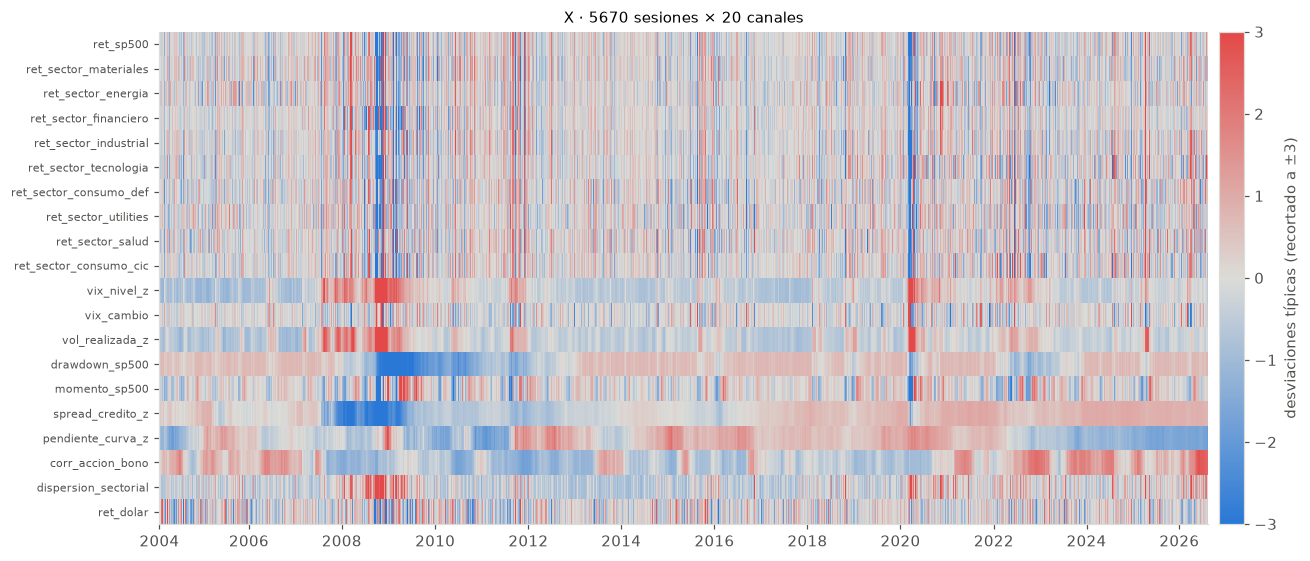

In [4]:
canales = features.construir_canales(precios)
causalidad = features.contraste_causalidad(precios)

print("X:", canales.shape, "·", canales.index[0].date(), "a", canales.index[-1].date())
print("Contraste causal superado:", int(causalidad["causal"].sum()), "de", len(causalidad))
print("Sesiones que consume el arranque de los z-score:", len(precios) - len(canales))

fig, eje = plt.subplots(figsize=(12, 5.2))
viz.mapa_canales(canales, eje=eje)
viz.guardar(fig, "mapa_canales")

## 3 · Las variables objetivo

Miran al futuro a propósito: son la etiqueta, no una entrada. Para la ventana que
termina en `t` se calculan sobre los 21 días **siguientes**, sin incluir `t`.

- `vol_futura` — volatilidad realizada anualizada. Es la tarea de regresión.
- `ret_futuro` y `dd_futuro` — retorno acumulado y caída máxima, de apoyo.

El régimen, que es la tarea principal, no se calcula aquí: sale del HMM del
cuaderno 01, que se ajusta solo con el tramo de entrenamiento.

Se guarda `objetivos` completo y `canales` recortado. El cuaderno 02 los alinea
por fecha, así que recortar aquí no cambiaría ni una ventana.

In [5]:
objetivos = features.objetivos(precios, config.ventanas().horizonte)
src.DIR_PROCESADO.mkdir(parents=True, exist_ok=True)

canales.to_parquet(src.DIR_PROCESADO / "canales.parquet")
objetivos.to_parquet(src.DIR_PROCESADO / "objetivos.parquet")

print("canales.parquet  ", canales.shape, "· huella", datos.huella(canales))
print("objetivos.parquet", objetivos.shape, "·", ", ".join(objetivos.columns))
objetivos.loc[canales.index].describe().T.round(3)

canales.parquet   (5670, 20) · huella eff86c43c3da
objetivos.parquet (5942, 3) · vol_futura, ret_futuro, dd_futuro


,count,mean,std,min,25%,50%,75%,max
vol_futura,5649.0,0.156,0.108,0.035,0.094,0.128,0.181,0.976
ret_futuro,5649.0,0.007,0.046,-0.400,-0.013,0.013,0.033,0.224
dd_futuro,5649.0,-0.041,0.042,-0.400,-0.050,-0.029,-0.016,-0.003


---

# 4 · Mini EDA

El dataset ya está escrito. Quedan tres preguntas, y sus respuestas se usan en los
cuadernos 05 a 14.

## 4.1 · ¿Cuántos datos independientes hay de verdad?

Muchos menos de los que parece. Dos ventanas consecutivas comparten 59 de sus 60
días, así que contar ventanas infla el tamaño muestral unas 80 veces.

En la figura cada celda es un bloque que **no comparte ni una sesión** con sus
vecinas: se pueden contar con la vista. Las teñidas, las que contienen estrés, son
un puñado, y solo las de train alimentan a los generadores.

sesiones              5670.0
ventanas_nominales    5590.0
bloques_disjuntos       70.0
factor_inflacion        79.9
Episodios de estrés: 11 · en train: 7 · en train de más de un mes: 2


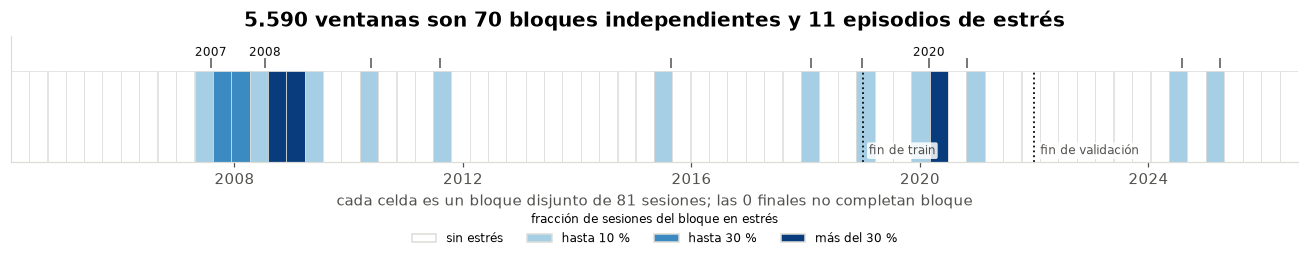

In [6]:
efectivo = ventanas.tamano_muestral_efectivo(canales.index, config.ventanas())
episodios = features.episodios_estres(canales["vix_nivel_z"])
en_train = episodios[episodios["inicio"] <= config.particiones().train_hasta]

print(efectivo.to_string())
print("Episodios de estrés:", len(episodios), "· en train:", len(en_train),
      "· en train de más de un mes:", int((en_train["sesiones_estres"] > config.ventanas().horizonte).sum()))

fig, eje = plt.subplots(figsize=(12, 2.8))
viz.carril_bloques(canales["vix_nivel_z"] > 2, episodios, config.ventanas(), config.particiones(), eje=eje)
viz.guardar(fig, "muestra_efectiva")

## 4.2 · ¿Podría generar esto una gaussiana?

Es la pregunta que justifica usar modelos generativos y no un muestreo
estadístico. Se responde midiendo los hechos estilizados de Cont (2001) sobre los
datos reales y comparándolos con procesos de respuesta conocida.

**La figura** enseña las dos propiedades más difíciles de imitar: las colas —×123
más días extremos de los que admite una normal— y la memoria de la magnitud, que
sigue viva 100 sesiones después.

**La tabla** añade la comparación. Cada proceso reproduce algo y falla en algo:

| proceso | colas | memoria | colas condicionales |
|---|---|---|---|
| `gaussiano` · una normal única | ✗ 3,0 | ✗ 0,00 | ✗ 3,4 |
| `t4` · colas gruesas sin más | ✓ 11,1 | ✗ 0,00 | ✗ 12,4 |
| `garch11` · volatilidad variable | ✓ 7,5 | ✓ 0,24 | ✗ 3,2 |
| `mezcla` · una normal por régimen | ✓ 8,0 | ✓ 0,31 | ✗ 3,5 |
| **el mercado** | **16,5** | **0,31** | **7,2** |

`mezcla` es la fila que importa: **es lo que produce nuestro generador
gaussiano**, porque D10 ajusta un modelo por régimen y eso no es una normal, es
una mezcla. Reproduce colas y memoria, así que predecir su fracaso por ahí habría
sido un error.

Lo que ninguno reproduce es la última columna. Al dividir cada retorno por la
volatilidad de las 21 sesiones anteriores, al mercado le siguen quedando colas y a
ellos no. De ahí sale la hipótesis del trabajo:

> **H1** · `curtosis_residuos` del mercado = **7,2**, banda bootstrap
> **[5,6 – 10,3]**. Los cuatro procesos caen fuera.
> **Se refuta si un generador gaussiano entra en la banda.**

Dos cautelas, dichas antes de que las pregunten: la curtosis cruda es frágil —cae
de 16,5 a 14,7 al quitar un solo día, el 16 de marzo de 2020— y por eso no se usa
como criterio; y `beta_acf_abs` se calcula pero se retira de la tabla, porque su
banda mide [0,35 – 1,20] y con esa anchura no decide nada.

,sp500,financiero,consumo_cic,energia,banda_inf,banda_sup,gaussiano,t4,garch11,mezcla
curtosis,16.470,20.566,11.213,16.081,7.264,21.478,2.983,11.112,7.483,8.026
curtosis_h21,6.790,10.412,5.328,9.827,3.910,24.171,2.704,3.187,5.533,7.156
curtosis_residuos,7.229,6.122,5.088,5.256,5.567,10.297,3.354,12.426,3.199,3.447
asimetria,-0.476,-0.209,-0.471,-0.713,-0.831,-0.159,0.006,0.104,-0.025,0.140
ac1_retorno,-0.117,-0.111,-0.047,-0.053,-0.188,-0.042,-0.007,0.010,0.014,0.010
ac1_absoluto,0.313,0.429,0.268,0.258,0.165,0.406,-0.009,0.002,0.243,0.310
ac10_absoluto,0.308,0.370,0.256,0.269,0.163,0.357,0.002,0.003,0.226,0.257
ac40_absoluto,0.160,0.320,0.182,0.141,0.053,0.195,0.014,0.005,0.167,0.097
ac100_absoluto,0.084,0.199,0.109,0.082,-0.018,0.112,-0.002,-0.005,0.082,-0.007
apalancamiento,-0.099,-0.068,-0.054,-0.111,-0.129,-0.063,0.001,-0.010,0.012,0.013


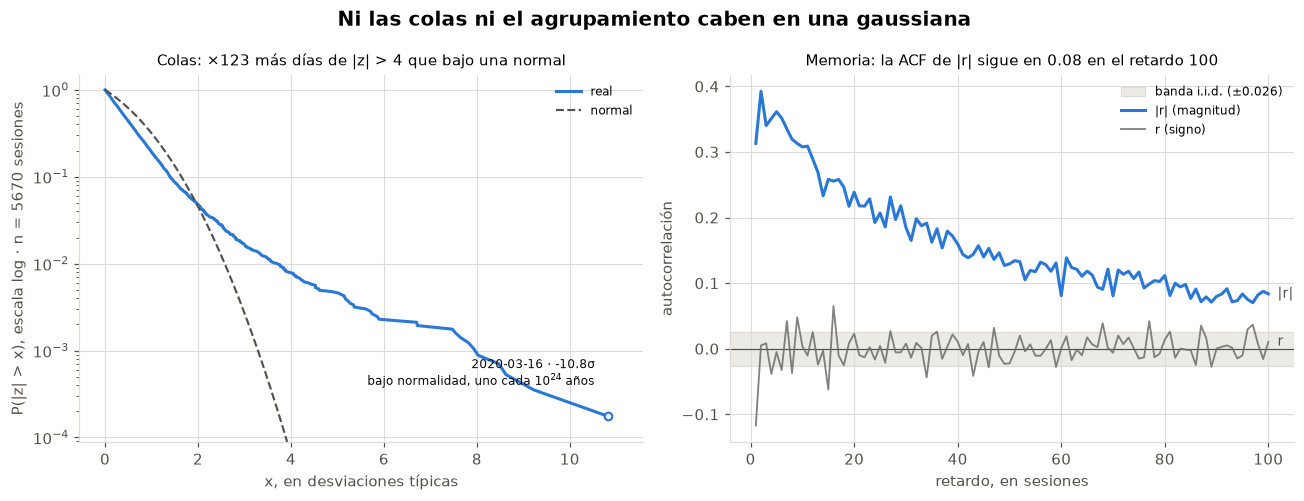

In [7]:
r = canales["ret_sp500"]
extremos = ["ret_sp500", "ret_sector_financiero", "ret_sector_consumo_cic", "ret_sector_energia"]
tabla = (features.hechos_estilizados(canales[extremos])
         .drop(index="beta_acf_abs")   # banda [0,35 - 1,20]: demasiado ancha para decidir nada
         .rename(columns=lambda c: c.replace("ret_sector_", "").replace("ret_", ""))
         .join(features.banda_bootstrap(r)).join(features.calibracion_hechos()))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
viz.supervivencia_colas(r, eje=ejes[0])
viz.autocorrelacion_absolutos(r, eje=ejes[1])
fig.suptitle("Ni las colas ni el agrupamiento caben en una gaussiana", fontsize=13, fontweight="bold")
viz.guardar(fig, "colas_y_agrupamiento")

tabla.round(3)

## 4.3 · ¿Qué aporta cada canal?

Dos preguntas sobre las mismas 20 filas, ordenadas igual para poder leerlas a la
vez.

**Escala** (izquierda): el canal más disperso tiene 411 veces la desviación del
menos disperso. Sin escalar por canal, un modelo optimizaría uno solo e ignoraría
el resto. Es la justificación del escalado del cuaderno 02.

**Señal** (derecha): AUC de cada canal usado como único predictor de "el próximo
mes estará en el decil superior de volatilidad", medido **solo sobre train**. Seis
canales pasan de 0,70 y todos son derivados; el mejor retorno se queda en 0,55.
Sin las derivadas, la tarea de régimen no tendría de dónde agarrarse.

El AUC va sin banda y conviene decirlo: con el mismo bootstrap ronda ±0,15, así
que lo defendible es la separación entre los dos bloques, no el orden entre
canales vecinos.

AUC sobre train · 3755 ventanas, 376 positivas
Correlación media entre sectores · calma 0.615 · estrés 0.786


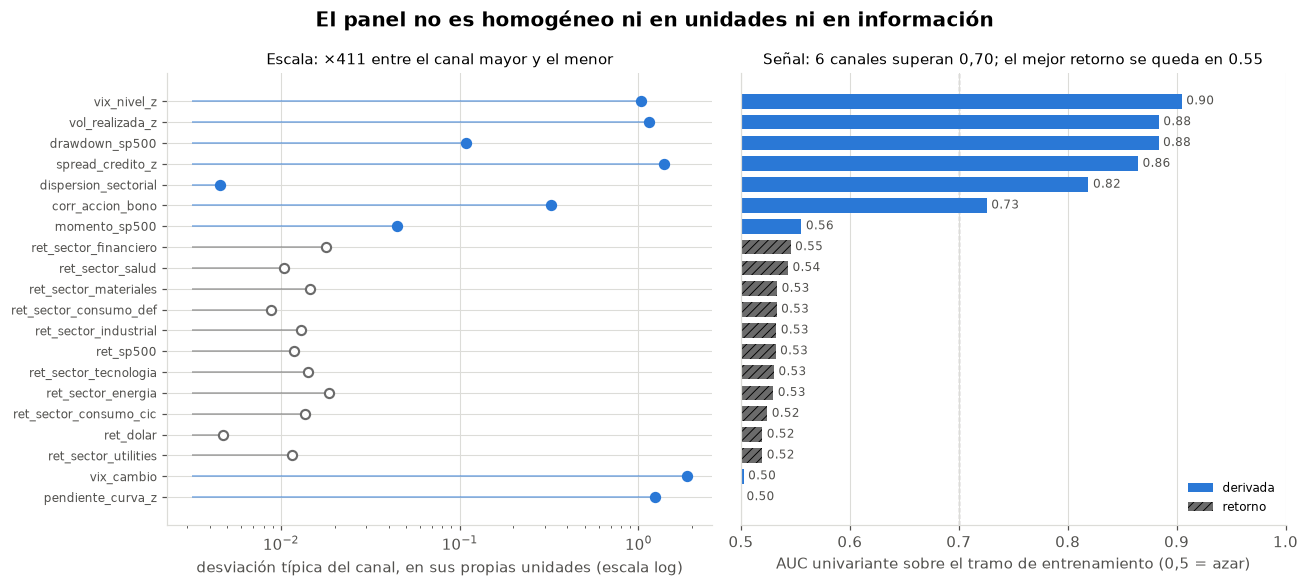

In [8]:
familias = config.familias_canales()
auc = features.auc_univariante(canales, objetivos["vol_futura"], hasta=config.particiones().train_hasta)
correlacion = features.correlacion_media(canales, objetivos["vol_futura"], hasta=config.particiones().train_hasta)

print("AUC sobre train ·", int(auc["n"].iloc[0]), "ventanas,", int(auc["positivos"].iloc[0]), "positivas")
print("Correlación media entre sectores · calma", round(correlacion["calma"], 3), "· estrés", round(correlacion["estres"], 3))

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.4), sharey=True)
viz.puntos_escala(canales.std().reindex(auc.index), familias, eje=ejes[0])
viz.barras_auc(auc["auc"], familias, eje=ejes[1]); ejes[1].tick_params(axis="y", length=0)
fig.suptitle("El panel no es homogéneo ni en unidades ni en información", fontsize=13, fontweight="bold")
viz.guardar(fig, "perfil_de_canales")

## Qué se lleva el resto del proyecto

- **El dataset.** `canales.parquet` (5.670 × 20) y `objetivos.parquet`. El
  cuaderno 01 usa 5 canales para el HMM; el 02 los apila en ventanas.
- **La hipótesis H1**, que los cuadernos 05 a 10 tienen que intentar refutar.
- **El tamaño muestral efectivo**, que es lo que hay que citar en cualquier
  intervalo de confianza: 70 bloques y 2 crisis en train, no 5.590 ventanas.
- **Un protocolo.** La ACF de |r| de las muestras sintéticas se mide agrupando
  todos los pares de todas las ventanas, nunca ventana a ventana promediando
  después: sobre estos mismos datos, la segunda forma da 0,018 en vez de 0,313 y
  daría por bueno a un generador sin ninguna memoria.

## Salidas generadas

In [9]:
from pathlib import Path

salidas = [
    src.DIR_CRUDO / "precios.parquet",
    src.DIR_PROCESADO / "canales.parquet",
    src.DIR_PROCESADO / "objetivos.parquet",
    src.DIR_FIGURAS / "panel_mercado.png",
    src.DIR_FIGURAS / "mapa_canales.png",
    src.DIR_FIGURAS / "muestra_efectiva.png",
    src.DIR_FIGURAS / "colas_y_agrupamiento.png",
    src.DIR_FIGURAS / "perfil_de_canales.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))

[ok] data\raw\precios.parquet
[ok] data\processed\canales.parquet
[ok] data\processed\objetivos.parquet
[ok] results\figures\panel_mercado.png
[ok] results\figures\mapa_canales.png
[ok] results\figures\muestra_efectiva.png
[ok] results\figures\colas_y_agrupamiento.png
[ok] results\figures\perfil_de_canales.png
